# Imports

In [1]:
import yaml
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
import random

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection import MeanAveragePrecision

import albumentations as A
from albumentations.pytorch import ToTensorV2

torch.manual_seed(1337)
np.random.seed(1337)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Imports successful")

Imports successful


# Config

In [2]:
CONFIG = {
    'dataset_path': 'condition_detection_data',
    'model_name': 'retinanet_resnet50_fpn_v2',
    'epochs': 100,
    'batch_size': 8,
    'imgsz': 640,
    'lr': 0.0001,
    'patience': 20,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'project': 'condition_detection',
    'name': 'retinanet',
    'num_workers': 4,
    'save_interval': 10
}

dataset_path = Path(CONFIG['dataset_path'])
project_path = Path(CONFIG['project']) /CONFIG['name']
project_path.mkdir(parents=True, exist_ok=True)

print(f"Dataset Path: {dataset_path}")
print(f"Project Path: {project_path}")
print(f"\nConfig:")
for key, value in CONFIG.items():
    print(f"    {key}: {value}")

Dataset Path: condition_detection_data
Project Path: condition_detection/retinanet

Config:
    dataset_path: condition_detection_data
    model_name: retinanet_resnet50_fpn_v2
    epochs: 100
    batch_size: 8
    imgsz: 640
    lr: 0.0001
    patience: 20
    device: cuda
    project: condition_detection
    name: retinanet
    num_workers: 4
    save_interval: 10


In [3]:
yaml_path = dataset_path / 'data.yaml'

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
print("data.yaml loaded")
print(f"\nDataset Config:")
print(f"    Classes: {data_config['names']}")
print(f"    Number of classes: {len(data_config['names'])}")

data.yaml loaded

Dataset Config:
    Classes: ['Good', 'Heavily Damaged', 'Weathered']
    Number of classes: 3


# Dataset Class for YOLO Format

In [4]:
class YOLODataset(Dataset):
    # convert from x_center y_center width height (normalised)
    #           to [x_min, y_min, x_max, y_max]   (abs coords)

    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transforms = transforms

        # get all imgs
        self.image_files = list(self.images_dir.glob('*.jpg'))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # load img
        img_path = self.image_files[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        height, width = image.shape[:2]

        # load yolo format labels
        label_path = self.labels_dir / f"{img_path.stem}.txt"
        boxes = []
        labels = []

        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_center, y_center, box_width, box_height = map(float, parts[1:5])

                        # yolo to pytorch
                        x_min = (x_center - box_width / 2) * width
                        y_min = (y_center - box_height / 2) * height
                        x_max = (x_center + box_width / 2) * width
                        y_max = (y_center + box_height / 2) * height

                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id + 1) # 0 is background

        # convert to tensors
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        # apply transforms
        if self.transforms:
            sample = self.transforms(image=image, bboxes=boxes.numpy(), labels=labels.numpy())
            image = sample['image']
            boxes = torch.as_tensor(sample['bboxes'], dtype=torch.float32)
            labels = torch.as_tensor(sample['labels'], dtype=torch.int64)

        target = {
            'boxes': boxes,
            'labels': labels,
        }

        # img to tensor
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return image, target

print("yolo dataset class defined")

yolo dataset class defined


# Data Transforms and DataLoaders

In [5]:
def get_train_transforms(img_size=640):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

def get_val_transforms(img_size=640):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = YOLODataset(
    images_dir=dataset_path / 'images/train',
    labels_dir=dataset_path / 'labels/train',
    transforms=get_train_transforms(CONFIG['imgsz'])
)

val_dataset = YOLODataset(
    images_dir=dataset_path / 'images/val',
    labels_dir=dataset_path / 'labels/val',
    transforms=get_val_transforms(CONFIG['imgsz'])
)

test_dataset = YOLODataset(
    images_dir=dataset_path / 'images/test',
    labels_dir=dataset_path / 'labels/test',
    transforms=get_val_transforms(CONFIG['imgsz'])
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_fn
)

print("Dataset and DataLoaders created")

Dataset and DataLoaders created


# RetinaNet Model Setup

In [6]:
def create_retinanet_model(num_classes):
    model = retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT)

    num_anchors = model.head.classification_head.num_anchors

    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )

    return model

num_classes = len(data_config['names']) + 1
model = create_retinanet_model(num_classes)
model = model.to(CONFIG['device'])

print(f"RetinaNet model created with {num_classes} classes, including background")
print(f"Model Loaded on: {CONFIG['device']}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"    Total parameters: {total_params:,}")
print(f"    Trainable parameters: {trainable_params:,}")

RetinaNet model created with 4 classes, including background
Model Loaded on: cuda
    Total parameters: 36,393,096
    Trainable parameters: 36,167,752


# Training Setup

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': [],
    'epoch': []
}

print("Optimizer and scheuler configured")
print(f" Optimiser: AdamW")
print(f" Initial learning rate: {CONFIG['lr']}")
print(f" Scheduler: ReduceLROnPlateau")

Optimizer and scheuler configured
 Optimiser: AdamW
 Initial learning rate: 0.0001
 Scheduler: ReduceLROnPlateau


# Training and Validation Functions

In [8]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        #forward
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        #backward
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if (i + 1) % 10 == 0:
            print(f"    Batch [{i+1}/{len(data_loader)}], Loss: {losses.item():.4f}")

    avg_loss = total_loss / len(data_loader)
    return avg_loss


@torch.no_grad()
def validate(model, data_loader, device):
    model.train()
    total_loss = 0

    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total_loss += losses.item()

    avg_loss = total_loss / len(data_loader)
    return avg_loss

@torch.no_grad()
def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision()

    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)

        preds = [{k: v.cpu() for k, v in output.items()} for output in outputs]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

        metric.update(preds, targets_cpu)

    results = metric.compute()
    return results

print(" Training and validation functions defined")

 Training and validation functions defined


# Model Training

In [9]:
print("\nRetinaNet Training")

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch [{epoch+1}/{CONFIG['epochs']}]")

    train_loss = train_one_epoch(model, optimizer, train_loader, CONFIG['device'], epoch)
    print(f"    Training Loss: {train_loss:.4f}")

    val_loss = validate(model, val_loader, CONFIG['device'])
    print(f"    Validation Loss: {val_loss:.4f}")

    lr_scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"    Learning Rate: {current_lr:.4f}")
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(current_lr)
    history['epoch'].append(epoch + 1)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, project_path / 'best_model.pth')
        print(f"    Best model saved (val_loss: {val_loss:.4f})")

    else:
        patience_counter += 1

    if (epoch + 1) % CONFIG['save_interval'] == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, project_path / f'checkpoint_epoch_{epoch+1}.pth')
        print(f"    Checkpoint saved at epochh {epoch+1}")

    if patience_counter >= CONFIG['patience']:
        print(f"\n    Early stopping triggered after {epoch + 1} epochs")
        break

torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_loss': val_loss,
}, project_path / 'final_model.pth')

history_df = pd.DataFrame(history)
history_df.to_csv(project_path / 'training_history.csv', index=False)

print("\nRetinaNet Training Complete")


RetinaNet Training

Epoch [1/100]
    Batch [10/47], Loss: 0.7414
    Batch [20/47], Loss: 0.4859
    Batch [30/47], Loss: 0.8460
    Batch [40/47], Loss: 0.4851
    Training Loss: 0.6951
    Validation Loss: 0.7317
    Learning Rate: 0.0001
    Best model saved (val_loss: 0.7317)

Epoch [2/100]
    Batch [10/47], Loss: 0.3704
    Batch [20/47], Loss: 0.6481
    Batch [30/47], Loss: 0.3487
    Batch [40/47], Loss: 0.5520
    Training Loss: 0.5165
    Validation Loss: 0.6511
    Learning Rate: 0.0001
    Best model saved (val_loss: 0.6511)

Epoch [3/100]
    Batch [10/47], Loss: 0.5917
    Batch [20/47], Loss: 0.5672
    Batch [30/47], Loss: 0.6113
    Batch [40/47], Loss: 0.4476
    Training Loss: 0.6190
    Validation Loss: 0.6746
    Learning Rate: 0.0001

Epoch [4/100]
    Batch [10/47], Loss: 0.6340
    Batch [20/47], Loss: 0.5896
    Batch [30/47], Loss: 0.5952
    Batch [40/47], Loss: 0.5388
    Training Loss: 0.6432
    Validation Loss: 0.8510
    Learning Rate: 0.0001

Epoch [

# Training Metrics

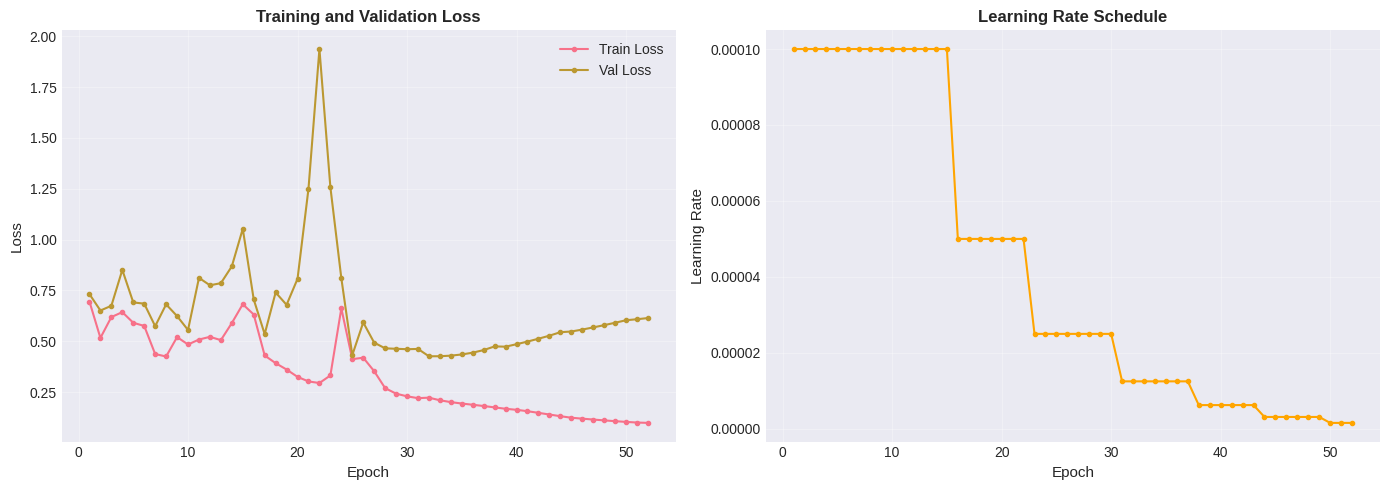

Training metrics saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['learning_rate'], color='orange', marker='o', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Learning Rate', fontsize=11)
axes[1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(project_path / 'training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training metrics saved")

In [11]:
@torch.no_grad()
def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(backend='faster_coco_eval')

    for images, targets in data_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        predictions = model(images)

        metric.update(predictions, targets)

    return metric.compute()

checkpoint = torch.load(project_path / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"    Best model loaded(epoch {checkpoint['epoch']}, val_loss: {checkpoint['val_loss']:.4f})")

print("\nEvaluating on validation set")
val_metrics = evaluate_map(model, val_loader, CONFIG['device'])

print("Validation Results")
print(f"mAP50: {val_metrics['map_50'].item():.4f}")
print(f"mAP50-95: {val_metrics['map'].item():.4f}")
print(f"mAP75: {val_metrics['map_75'].item():.4f}")
print(f"mAP Small: {val_metrics['map_small'].item():.4f}")
print(f"mAP Medium: {val_metrics['map_medium'].item():.4f}")
print(f"mAP Large: {val_metrics['map_large'].item():.4f}")

print("\nEvaluating on test set")
test_metrics = evaluate_map(model, test_loader, CONFIG['device'])

print("Test Results")
print(f"mAP50: {test_metrics['map_50'].item():.4f}")
print(f"mAP50-95: {test_metrics['map'].item():.4f}")
print(f"mAP75: {test_metrics['map_75'].item():.4f}")
print(f"mAP Small: {test_metrics['map_small'].item():.4f}")
print(f"mAP Medium: {test_metrics['map_medium'].item():.4f}")
print(f"mAP Large: {test_metrics['map_large'].item():.4f}")


    Best model loaded(epoch 31, val_loss: 0.4261)

Evaluating on validation set
Validation Results
mAP50: 0.3594
mAP50-95: 0.2912
mAP75: 0.3226
mAP Small: 0.1000
mAP Medium: 0.2780
mAP Large: 0.3130

Evaluating on test set
Test Results
mAP50: 0.4057
mAP50-95: 0.3202
mAP75: 0.3828
mAP Small: 0.3000
mAP Medium: 0.4545
mAP Large: 0.3317


# Inference Examples

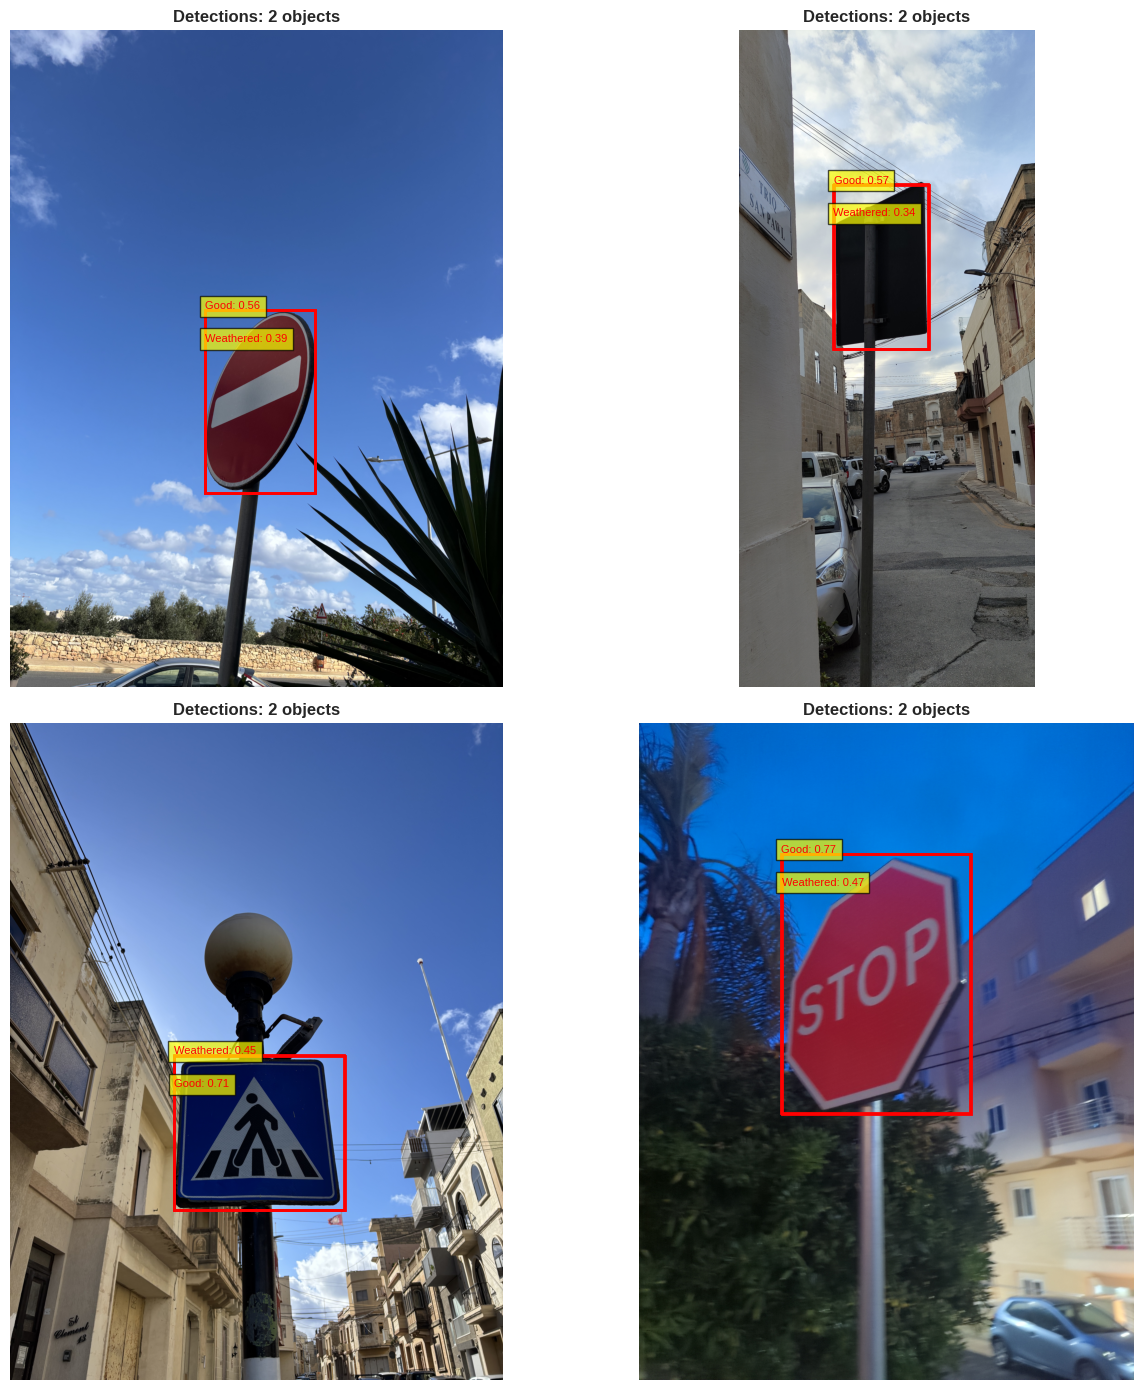

Inference visualisation saved


In [20]:
model.eval()

all_test_images = list((dataset_path / 'images/test').glob('*'))
test_images_paths = random.sample(all_test_images, min(4, len(all_test_images)))

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, img_path in enumerate(test_images_paths):
    image = cv2.imread(str(img_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    transform = get_val_transforms(CONFIG['imgsz'])
    transformed = transform(image=image_rgb, bboxes=[], labels=[])
    img_tensor = transformed['image'].unsqueeze(0).to(CONFIG['device'])

    with torch.no_grad():
        predictions = model(img_tensor)

    ax = axes[idx]
    ax.imshow(image_rgb)

    pred = predictions[0]
    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()

    threshold = 0.325
    
    valid_detections = []
    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x1, y1, x2, y2 = box
            x1 = x1 * w / CONFIG['imgsz']
            y1 = y1 * h / CONFIG['imgsz']
            x2 = x2 * w / CONFIG['imgsz']
            y2 = y2 * h / CONFIG['imgsz']
            
            valid_detections.append({
                'box': [x1, y1, x2, y2],
                'label': label,
                'score': score
            })

    valid_detections.sort(key=lambda x: x['box'][1])

    last_text_y = -100
    text_height_buffer = h * 0.05

    for det in valid_detections:
        x1, y1, x2, y2 = det['box']
        label = det['label']
        score = det['score']

        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        class_name = data_config['names'][label-1]
        
        
        text_y = y1 - 5
        
        if text_y < 0:
            text_y = y1 + 15 

        if abs(text_y - last_text_y) < text_height_buffer:
            text_y = last_text_y + text_height_buffer

        last_text_y = text_y

        ax.text(x1, text_y, f"{class_name}: {score:.2f}", 
                color='red', fontsize=8, 
                bbox=dict(facecolor='yellow', alpha=0.7))

    ax.set_title(f"Detections: {len(valid_detections)} objects", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(project_path / 'inference_examples.png', dpi=300, bbox_inches='tight')
plt.show()

print("Inference visualisation saved")


# Evaluation Metrics

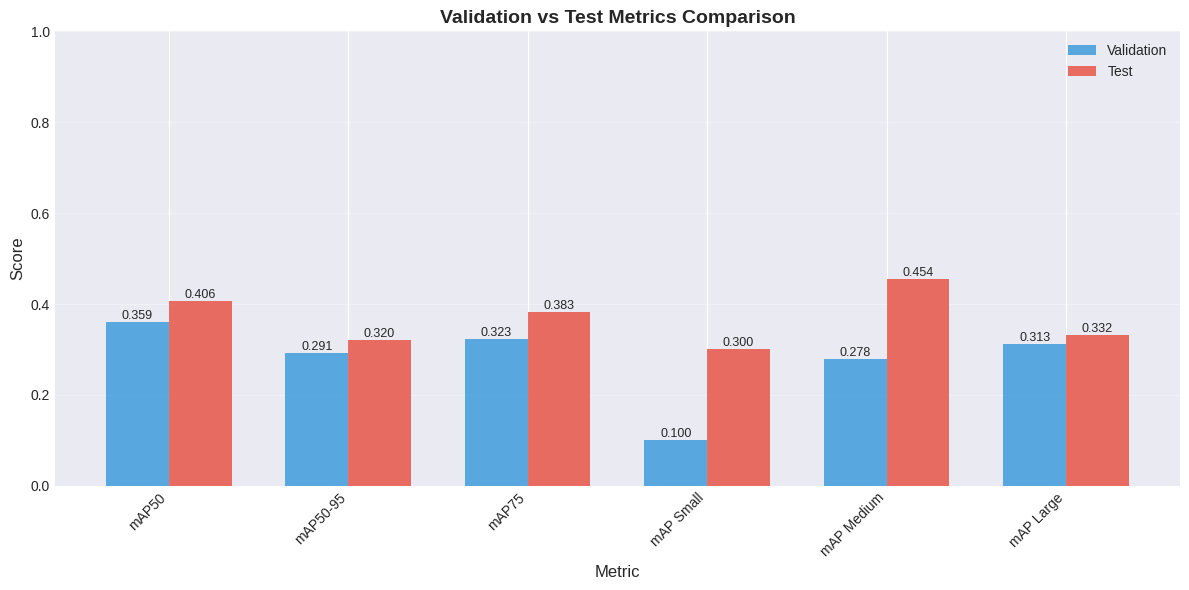

Evaluation metrics visualization saved

EVALUATION METRICS SUMMARY
Metric                    Validation            Test Difference
------------------------------------------------------------
mAP50                         0.3594          0.4057     0.0463
mAP50-95                      0.2912          0.3202     0.0290
mAP75                         0.3226          0.3828     0.0603
mAP Small                     0.1000          0.3000     0.2000
mAP Medium                    0.2780          0.4545     0.1765
mAP Large                     0.3130          0.3317     0.0187


In [13]:
val_metrics_dict = {
    'mAP50': val_metrics['map_50'].item(),
    'mAP50-95': val_metrics['map'].item(),
    'mAP75': val_metrics['map_75'].item(),
    'mAP Small': val_metrics['map_small'].item(),
    'mAP Medium': val_metrics['map_medium'].item(),
    'mAP Large': val_metrics['map_large'].item()
}

test_metrics_dict = {
    'mAP50': test_metrics['map_50'].item(),
    'mAP50-95': test_metrics['map'].item(),
    'mAP75': test_metrics['map_75'].item(),
    'mAP Small': test_metrics['map_small'].item(),
    'mAP Medium': test_metrics['map_medium'].item(),
    'mAP Large': test_metrics['map_large'].item()
}

fig, ax = plt.subplots(figsize=(12, 6))

metric_names = list(val_metrics_dict.keys())
val_values = list(val_metrics_dict.values())
test_values = list(test_metrics_dict.values())

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_values, width, label='Validation', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, test_values, width, label='Test', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Validation vs Test Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)


for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(project_path / 'evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Evaluation metrics visualization saved")

# Optional: Create a summary table
print("\n" + "="*60)
print("EVALUATION METRICS SUMMARY")
print("="*60)
print(f"{'Metric':<20} {'Validation':>15} {'Test':>15} {'Difference':>10}")
print("-"*60)
for metric in metric_names:
    val_score = val_metrics_dict[metric]
    test_score = test_metrics_dict[metric]
    diff = test_score - val_score
    print(f"{metric:<20} {val_score:>15.4f} {test_score:>15.4f} {diff:>10.4f}")
print("="*60)


# Final Report

In [14]:
report = f"""
RetinaNET Sign Condition Detection


Dataset Information

Classes: {', '.join(data_config['names'])}
Number of Classes: {len(data_config['names'])}
Traning Samples: {len(train_dataset)}
Validation Samples: {len(val_dataset)}
Test Samples: {len(test_dataset)}


Model Architecture
Base Model: {CONFIG['model_name']}


Training Details

Total Epochs: {len(history['epoch'])}
Batch Size: {CONFIG['batch_size']}
Image Size: {CONFIG['imgsz']}x{CONFIG['imgsz']}
Initial Learning Rate: {CONFIG['lr']}
Optimiser: AdamW
Scheduler: ReduceLROnPlateau
Patience: {CONFIG['patience']}


Validation Performance

mAP50: {val_metrics['map_50'].item():.4f}
mAP50-95: {val_metrics['map'].item():.4f}
mAP75: {val_metrics['map_75'].item():.4f}
Best Validation Loss: {best_val_loss:.4f}


Test Performance

mAP50: {test_metrics['map_50'].item():.4f}
mAP50-95: {test_metrics['map'].item():.4f}
mAP75: {test_metrics['map_75'].item():.4f}


Model Files
Best Model: {project_path / 'best_model.pth'}
Final Model: {project_path / 'final_model.pth'}
Training History: {project_path / 'training_history.csv'}
"""

print(report)

with open(project_path / 'final_report.txt', 'w') as f:
    f.write(report)

print(f"\n Report saved to {project_path / 'final_report.txt'}")


RetinaNET Sign Condition Detection


Dataset Information

Classes: Good, Heavily Damaged, Weathered
Number of Classes: 3
Traning Samples: 371
Validation Samples: 69
Test Samples: 66


Model Architecture
Base Model: retinanet_resnet50_fpn_v2


Training Details

Total Epochs: 52
Batch Size: 8
Image Size: 640x640
Initial Learning Rate: 0.0001
Optimiser: AdamW
Scheduler: ReduceLROnPlateau
Patience: 20


Validation Performance

mAP50: 0.3594
mAP50-95: 0.2912
mAP75: 0.3226
Best Validation Loss: 0.4261


Test Performance

mAP50: 0.4057
mAP50-95: 0.3202
mAP75: 0.3828


Model Files
Best Model: condition_detection/retinanet/best_model.pth
Final Model: condition_detection/retinanet/final_model.pth
Training History: condition_detection/retinanet/training_history.csv


 Report saved to condition_detection/retinanet/final_report.txt
